In [38]:
!pip install -q langchain langchain-google-genai google-generativeai pydantic

I0720 15:26:06.748486 1687145 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(76, generation: 1)


In [23]:
!pip install python-dotenv

In [48]:
!pip install langchain-community

In [1]:
import os
from dotenv import load_dotenv

# Load the variables from your .env file
load_dotenv()

# Access your API key
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [2]:
print(GEMINI_API_KEY)  # This will print your API key to verify it's loaded correctly

AQ.Ab8RN6J0pdn9yMIgZOMXJ7kEjIvAkUGlj1PcLJse48o-RGA3cw


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

In [6]:
respuesta = llm.invoke("Que es el RAG en Inteligencia Artifical")

In [50]:
respuesta.content

'**RAG** son las siglas en inglés de **Retrieval-Augmented Generation** (Generación Aumentada por Recuperación).\n\nEn términos sencillos, es una técnica que permite a los modelos de lenguaje (como ChatGPT) **consultar fuentes de información externas y privadas** antes de generar una respuesta, en lugar de depender únicamente de lo que aprendieron durante su entrenamiento.\n\nAquí te explico cómo funciona y por qué es tan importante:\n\n---\n\n### 1. El problema: ¿Por qué necesitamos RAG?\nLos modelos de IA tradicionales (como GPT-4) tienen dos limitaciones principales:\n*   **Conocimiento estático:** Su entrenamiento se detuvo en una fecha específica. No saben qué pasó ayer o qué hay en tus documentos privados.\n*   **Alucinaciones:** Si le preguntas algo que no saben, a veces "inventan" una respuesta que suena convincente pero es falsa.\n\n### 2. ¿Cómo funciona el RAG? (El proceso)\nImagina que el modelo de IA es un estudiante brillante, pero que no tiene acceso a internet ni a libro

In [7]:
PROMPT_TRIAGE = """
Eres un especialista en triaje del Service Desk para politicas internas.
Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
{\n
    "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",\n
    "urgency": "BAJA" | "MEDIANA" | "ALTA",\n
    "missing_fields": ["..."]\n
}\n
Reglas:\n
- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las politicas (Ej.: "¿Puedo reembolsar el internet para mi oficina en casa?").\n
- **PEDIR_INFO**: Mensajes imprecisos o sin información para identificar el tema o el contexto (Ej.: "Necesito ayuda con una politica").\n
- **ABRIR_TICKET**: Solicitudes de excepciones, autorización, aprobación o acceso especial, o cuando el usuario solicita explicitamente abrir un ticket (Ej.: "Quiero una excepción para trabajar remotamente durante 5 dias").\n
Analiza el mensaje y decide la acción más adecuada.
"""

In [8]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

In [9]:
class Triage(BaseModel):
  decision: Literal["AUTO_RESOLVER","PEDIR_INFO","ABRIR_TICKET"]
  urgency: Literal["BAJA","MEDIANA","ALTA"]
  missing_fields: List[str] = Field(default_factory=list)

In [10]:
from langchain_core.messages import SystemMessage, HumanMessage

In [11]:
triage_chain = llm.with_structured_output(Triage)

def triage(msg: str) -> Dict:
    response: Triage = triage_chain.invoke(
        [
            SystemMessage(content=PROMPT_TRIAGE),
            HumanMessage(content=msg)
        ]
    )
    return response.model_dump()

In [12]:
questions = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una política para anticipos de vacaciones?",
    "¿Quién fue Napoleón Bonaparte?"
]

In [13]:
for q in questions:
  print(f"Question: {q} -> {triage(q)}")

Question: ¿Puedo obtener un reembolso por el internet de mi home office? -> {'decision': 'AUTO_RESOLVER', 'urgency': 'BAJA', 'missing_fields': []}
Question: Quiero una excepción para teletrabajar durante 5 días. -> {'decision': 'ABRIR_TICKET', 'urgency': 'MEDIANA', 'missing_fields': ['fecha_inicio', 'motivo_de_la_excepcion']}
Question: ¿Cómo funciona la política de comidas para viajes? -> {'decision': 'AUTO_RESOLVER', 'urgency': 'BAJA', 'missing_fields': []}
Question: ¿Existe una política para anticipos de vacaciones? -> {'decision': 'AUTO_RESOLVER', 'urgency': 'BAJA', 'missing_fields': []}
Question: ¿Quién fue Napoleón Bonaparte? -> {'decision': 'AUTO_RESOLVER', 'urgency': 'BAJA', 'missing_fields': []}


# RAG    

In [15]:
!pip install -q langchain_community faiss_cpu langchain-text-splitters pymupdf

Python(85327) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [16]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

/var/folders/1b/3plyy51n7yq4l71722c2xvl80000gn/T/ipykernel_73137/3668488044.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


In [21]:
docs = []

for file in Path("files/").glob("*.pdf"):
  try:
    loader = PyMuPDFLoader(str(file))
    docs.extend(loader.load())
    print(f"File loaded: {file.name}")
  except Exception as e:
    print(f"Error loading file: {file.name}. Error: {e}")

print(f"Total files loaded: {len(docs)}")


File loaded: Política de Uso de Correo Electrónico y Seguridad de la Información.pdf
File loaded: Política de Teletrabajo (Home Office).pdf
File loaded: Política de Reembolsos (Viajes y Gastos).pdf
Total files loaded: 3


In [22]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [23]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

In [24]:
for chunk in chunks:
  print(chunk)
  print("-"*20)

page_content='Política de Uso de Correo Electrónico 
y Seguridad de la Información 
1. Propósito Esta política define el uso aceptable de los sistemas de correo electrónico de 
la empresa y las responsabilidades de los empleados para proteger la información' metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': 'files/Política de Uso de Correo Electrónico y Seguridad de la Información.pdf', 'file_path': 'files/Política de Uso de Correo Electrónico y Seguridad de la Información.pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}
--------------------
page_content='corporativa contra accesos no autorizados, pérdida o divulgación. 
2. Uso del Correo Electrónico (E-mail) 
●​ Uso Profesional: La cuenta de correo electrónico es una herramienta de trabajo y 
debe usarse principal

# Embeddings

In [25]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [26]:
embedding_model = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

In [27]:
from langchain_community.vectorstores import FAISS

In [28]:
vector_storage = FAISS.from_documents(documents=chunks, embedding=embedding_model)

In [29]:
retriever = vector_storage.as_retriever(
  search_type="similarity_score_threshold",
  search_kwargs={
      "score_threshold": 0.3,
      "k": 4
      }
)

# RAG

In [30]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain


In [31]:
prompt_rag = ChatPromptTemplate(
    [
        ("system",
            """Eres el especialista en RR.HH. de la empresa Carraro Desarrollo de Software.
            Tu objetivo es responder de manera concisa y directa a las preguntas del empleado, basándote estrictamente en el contexto proporcionado.
            Si la información necesaria para responder a la pregunta no se encuentra en el 'Contexto' proporcionado, tu respuesta debe ser ÚNICAMENTE '<NO_INFO>'. No añadas explicaciones ni información adicional si no tienes la respuesta.
            """
        ),
        ("human", "Contexto: {context}\nPregunta del empleado: {input}")
    ]
)

In [32]:
document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt_rag,
)

In [33]:
from typing import Dict

def seek_rag_answer(question: str) -> Dict:
  no_info_response = {
      "answer": "<NO_INFO>",
      "citations": [],
      "docs_sought": False
  }

  docs = retriever.invoke(question)

  if not docs:
    return no_info_response

  answer_content = document_chain.invoke({
      "input": question,
      "context": docs
  })

  if answer_content == "<NO_INFO>":
    return no_info_response
  else:
    citations = list(set([
        d.metadata.get('file_path', d.metadata.get('source', 'Unknown Source'))
        for d in docs
    ]))

    return {
        "answer": answer_content,
        "citations": citations,
        "docs_sought": True
    }

In [34]:
seek_rag_answer(questions[3])

{'answer': '<NO_INFO>', 'citations': [], 'docs_sought': False}

In [35]:
for q in questions:
  rag_answer = seek_rag_answer(q)
  print(f"Question: {q}")
  print(f"Answer: {rag_answer['answer']}")

  if rag_answer["docs_sought"] and rag_answer["answer"] not in ["<NO_INFO>", "No lo se."]:
    print(f"Citations: {rag_answer['citations']}")

Question: ¿Puedo obtener un reembolso por el internet de mi home office?
Answer: Sí, puedes solicitar un reembolso mensual de hasta 35 EUR presentando la factura correspondiente.
Citations: ['files/Política de Reembolsos (Viajes y Gastos).pdf', 'files/Política de Teletrabajo (Home Office).pdf']
Question: Quiero una excepción para teletrabajar durante 5 días.
Answer: Debes presentar tu solicitud por escrito al gerente y al departamento de RRHH, detallando la justificación. La solicitud será evaluada caso por caso.
Citations: ['files/Política de Teletrabajo (Home Office).pdf']
Question: ¿Cómo funciona la política de comidas para viajes?
Answer: Para viajes que requieran pernoctar, se establece una dieta diaria fija (viático) de 70 EUR para cubrir desayuno, almuerzo y cena. No es necesario presentar recibos para esta dieta.
Citations: ['files/Política de Reembolsos (Viajes y Gastos).pdf']
Question: ¿Existe una política para anticipos de vacaciones?
Answer: <NO_INFO>
Question: ¿Quién fue N

# LangGraph Agent

In [36]:
!pip install -q langgraph

Python(87410) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [37]:
from typing import TypedDict, Optional

In [39]:
class AgentState(TypedDict, total=False):
  question: str
  triage_decision: dict
  answer: Optional[str]
  citations: Optional[list]
  docs_sought: Optional[bool]
  rag_success: bool
  final_action: str



In [71]:
from langgraph.graph import START, END, StateGraph

In [133]:
workflow = StateGraph(AgentState)

In [134]:
workflow.add_edge(START, "triage")

In [135]:
def triage_node(state: AgentState) -> AgentState:
  print("Excuting 'triage' node...")
  return {"triage_decision": triage(state["question"])}

In [136]:
def triage_decision_edge(state: AgentState) -> str:
  decision = state.get("triage_decision", {}).get("decision")
  if decision == "AUTO_RESOLVER":
    return "auto_solve"
  elif decision == "PEDIR_INFO":
    return "ask_info"
  elif decision == "ABRIR_TICKET":
    return "open_ticket"
  else:
    raise ValueError(f"Unexpected triage decision: {decision}")

In [137]:
def auto_solve_decision_edge(state: AgentState) -> str:
    print(f"Deciding next step after 'AUTO_RESOLVER'")
 
    if state["rag_success"]:
        print(f"RAG was successful. Transitioning to 'END'.")
        return "go_to_end"
    
    OPEN_TICKER_KEYWORDS = ["aprobación", "excepción", "autorización", "acceso especial", "abrir ticket"]

    if any(keyword in state["question"].lower() for keyword in OPEN_TICKER_KEYWORDS):
        print(f"RAG failed and question contains keywords for opening a ticket. Transitioning to 'open_ticket'.")
        return "go_to_open_ticket"
    
    print("RAG failed and no keywords for opening a ticket found. Transitioning to 'ask_info'.")
    return "go_to_ask_info"

In [138]:
workflow.add_node("triage", triage_node)
workflow.add_node("auto_solve", auto_solve_node)
workflow.add_node("ask_info", ask_info_node)
workflow.add_node("open_ticket", open_ticket_node)


In [139]:
workflow.add_edge("ask_info", END);
workflow.add_edge("open_ticket", END);


In [141]:
def triage_decision_edge(state: AgentState):
  print("Deciding next step after 'triage' node...")

  triage_output = state["triage_decision"]
  
  decision = triage_output["decision"]

  if decision == "AUTO_RESOLVER":
    return "go_to_auto_solve"
  elif decision == "PEDIR_INFO":
    return "go_to_ask_info"
  elif decision == "ABRIR_TICKET":
    return "go_to_open_ticket"
  else:
    raise ValueError("Unknown triage decision")

In [142]:
def auto_solve_node(state: AgentState) -> AgentState:
  print("Excuting 'auto_solve' node...")
  answer = seek_rag_answer(state["question"])

  update: AgentState = {
      "answer": answer["answer"],
      "citations": answer["citations"],
      "rag_success": answer["docs_sought"]
  }

  if answer["docs_sought"]:
    update["final_action"] = "AUTO_RESOLVER"
  else:
    update["final_action"] = "PEDIR_INFO"

  return update

In [143]:
def ask_info_node(state: AgentState) -> AgentState:
  print("Excuting 'ask_info' node...")
  return {
      "asnswer": "I need more info about yout request.",
      "citations": [],
      "final_action": "go_to_ask_info"
  }

In [144]:
def open_ticket_node(state: AgentState) -> AgentState:
  print("Excuting 'open_ticket' node...")
  triage_decision = state["triage"]

  return {
      "answer": f"Open ticket as {triage_decision['urgency']} urgency.",
      "citations": [],
      "final_action": "go_to_open_ticket"
  }

In [145]:
workflow.add_conditional_edges("triage", triage_decision_edge, {
    "go_to_auto_solve": "auto_solve",
    "go_to_ask_info": "ask_info",
    "go_to_open_ticket": "open_ticket"
})

workflow.add_conditional_edges("auto_solve", auto_solve_decision_edge, {
    "go_to_ask_info": "ask_info",
    "go_to_open_ticket": "open_ticket",
    "go_to_end": END
})

In [146]:
graph = workflow.compile()

In [147]:
from IPython.display import display, Image

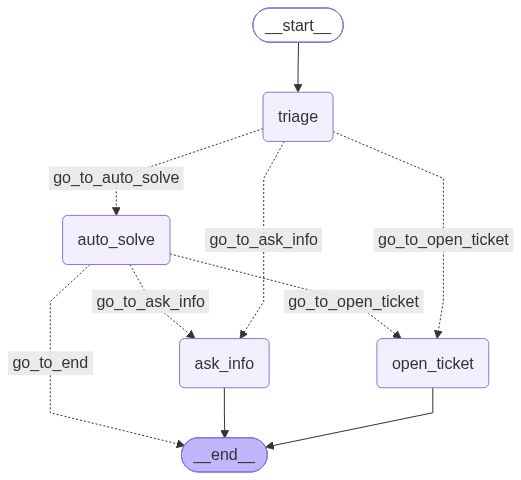

In [148]:
graph_bytes = graph.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [151]:
question = "¿Puedo obtener un reembolso por el internet de mi home office?"


agent_answer = graph.invoke({"question": question})

print(f"""
Question: {question}
Decision: {agent_answer['triage_decision']['decision']}
Urgency: {agent_answer['triage_decision']['urgency']}
Final Action: {agent_answer['final_action']}
Answer: {agent_answer.get('answer', 'No answer')}
""")

if rag_answer["citations"]:
  print(f"Citations: {rag_answer['citations']}")


Excuting 'triage' node...
Deciding next step after 'triage' node...
Excuting 'auto_solve' node...
Deciding next step after 'AUTO_RESOLVER'
RAG was successful. Transitioning to 'END'.

Question: ¿Puedo obtener un reembolso por el internet de mi home office?
Decision: AUTO_RESOLVER
Urgency: BAJA
Final Action: AUTO_RESOLVER
Answer: Sí, puedes solicitar un reembolso mensual de hasta 35 EUR presentando la factura correspondiente.

